# Импорты

In [1]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression, GammaRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder

from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score

import pickle
import matplotlib.pyplot as plt
%matplotlib inline

# Анализ и преобразование данных

In [2]:
df = pd.read_csv('data/carprice.csv', index_col='car_ID')
df.head()

,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
car_ID,,,,,,,,,,,,,,,,,,,,,
1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [130]:
df.columns

Index(['symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber',
       'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength',
       'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber',
       'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price'],
      dtype='object')

In [131]:
X = df.drop(['price'], axis=1)
y = df['price']

num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
print('Вещественные признаки\n', len(num_cols), num_cols)

str_cols = X.select_dtypes(include=['object']).columns
bin_cols = str_cols[np.where(X[str_cols].nunique() == 2)[0]].tolist()
print('\nБинарные признаки\n', len(bin_cols), bin_cols)

cat_cols = str_cols[np.where(X[str_cols].nunique() > 2)[0]].tolist()
print('\nКатегориальные признаки\n', len(cat_cols), cat_cols)

Вещественные признаки
 14 ['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']

Бинарные признаки
 4 ['fueltype', 'aspiration', 'doornumber', 'enginelocation']

Категориальные признаки
 6 ['CarName', 'carbody', 'drivewheel', 'enginetype', 'cylindernumber', 'fuelsystem']


Колонка с названиями автомобилей представлена в формате производитель + модель автомобиля, поэтому поделим эту колонку на 2 составные.

In [132]:
car_names = X['CarName'].str.split(' ', expand=True).fillna('')
X['car_company'] = car_names[0]
X['car_model'] = np.sum(car_names.loc[:, 1:], axis=1)

X.drop(['CarName'], axis=1, inplace=True)
cat_cols.remove('CarName')
cat_cols.append('car_company')
cat_cols.append('car_model')

Проверим, что в названии компаний &ndash; производителей автомобилей нет разных обозначений одной и той же компании. 

In [133]:
X['car_company'].value_counts()

car_company
toyota         31
nissan         17
mazda          15
honda          13
mitsubishi     13
subaru         12
volvo          11
peugeot        11
dodge           9
volkswagen      9
buick           8
bmw             8
audi            7
plymouth        7
saab            6
porsche         4
isuzu           4
alfa-romero     3
jaguar          3
chevrolet       3
renault         2
maxda           2
vw              2
mercury         1
porcshce        1
Nissan          1
toyouta         1
vokswagen       1
Name: count, dtype: int64

Приведем названия к единообразию.

In [134]:
X['car_company'] = X['car_company'].replace(
    {
        'maxda': 'mazda',
        'porcshce': 'porsche',
        'Nissan': 'nissan',
        'vokswagen': 'volkswagen',
        'vw': 'volkswagen',
        'toyouta': 'toyota',
      }
)

In [135]:
X['car_company'].value_counts()

car_company
toyota         32
nissan         18
mazda          17
mitsubishi     13
honda          13
subaru         12
volkswagen     12
volvo          11
peugeot        11
dodge           9
buick           8
bmw             8
audi            7
plymouth        7
saab            6
porsche         5
isuzu           4
alfa-romero     3
chevrolet       3
jaguar          3
renault         2
mercury         1
Name: count, dtype: int64

Переменная symboling также похожа на категориальную.

In [136]:
X['symboling'].value_counts()

symboling
 0    67
 1    54
 2    32
 3    27
-1    22
-2     3
Name: count, dtype: int64

In [137]:
cat_cols.append('symboling')
num_cols.remove('symboling')

Рассмотрим распределение целевой переменной.

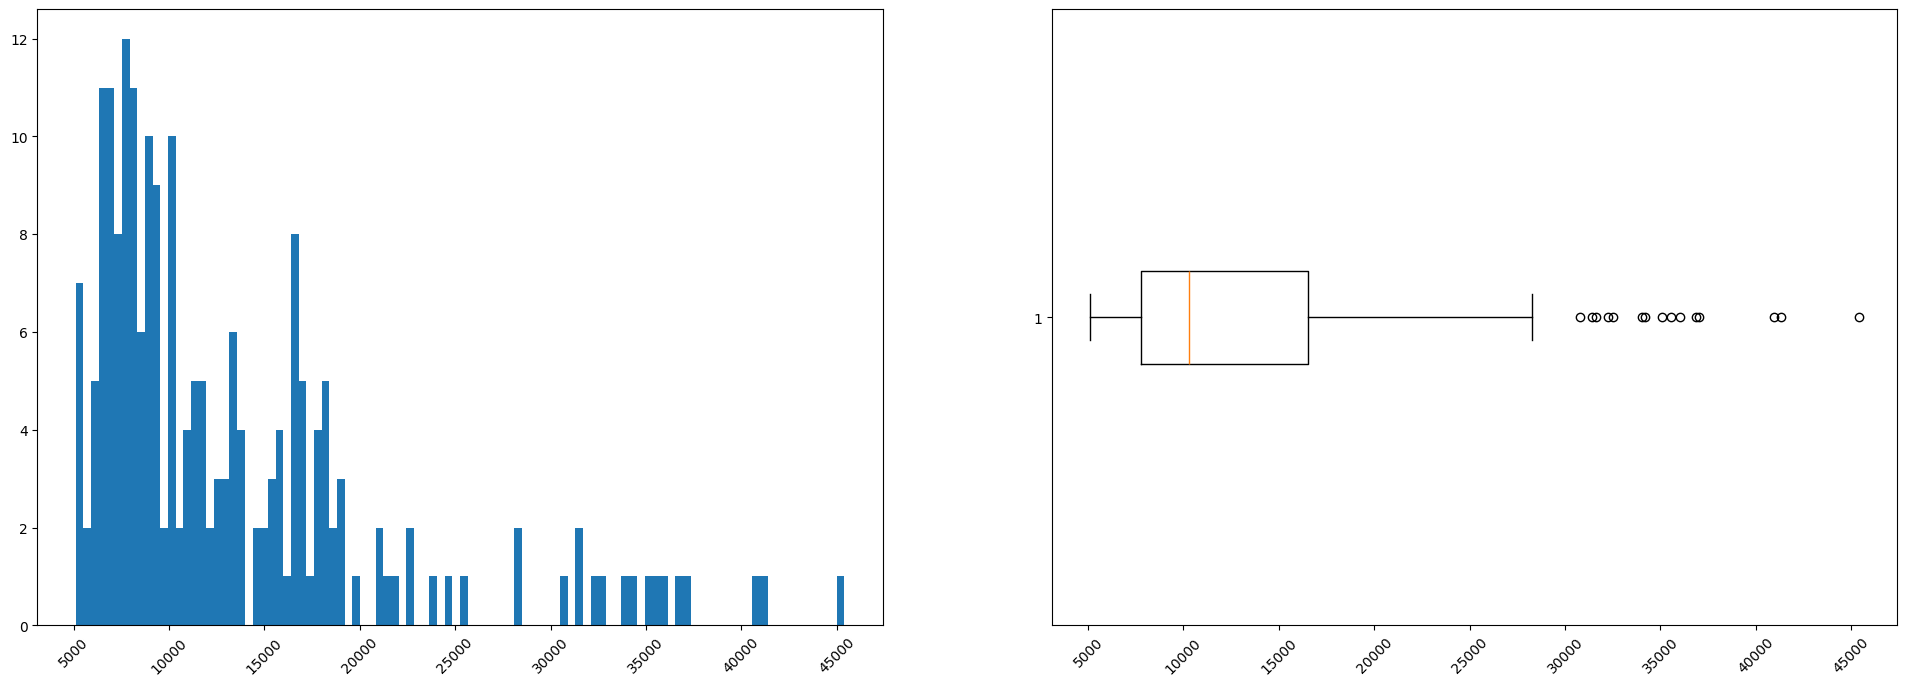

In [138]:
plt.figure(figsize=(24, 8))

plt.subplot(1, 2, 1)
plt.xticks(rotation=45)
plt.hist(y, bins=100)

plt.subplot(1, 2, 2)
plt.xticks(rotation=45)
plt.boxplot(y, vert=False)
plt.show()

In [148]:
config = {
    'num_cols': num_cols,
    'str_cols': list(str_cols),  # преобразуем Index в список
    'bin_cols': bin_cols,
    'cat_cols': cat_cols
}

In [149]:
import json
with open('config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=4, ensure_ascii=False)

# Обучение модели

In [139]:
def train_model(X,y):
    from sklearn.model_selection import GridSearchCV

    X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.66, # размер тестовой выборки
    random_state=42 # фиксируем как разбиваем выборку
    )

    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

    X_train_encoded = enc.fit_transform(X_train[bin_cols + cat_cols])
    X_test_encoded = enc.transform(X_test[bin_cols + cat_cols])

    X_train[bin_cols + cat_cols] = X_train_encoded
    X_test[bin_cols + cat_cols] = X_test_encoded

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    KNeighborsRegressor_model = KNeighborsRegressor(weights='distance',metric='minkowski')
    N_Neighbors = {"n_neighbors":[i for i in range (1,20)],"p":[1,2]}
    
    GCV = GridSearchCV(KNeighborsRegressor_model,
                      param_grid=N_Neighbors)
    GCV.fit(X_train, y_train)
    params = GCV.best_params_

    KNeighborsRegressor_model_fit = KNeighborsRegressor(n_neighbors=params['n_neighbors'],p=params['p']).fit(X_train, y_train)
    predict = KNeighborsRegressor_model_fit.predict(X_test)
    print(f"mean_absolute_percentage_error: {mean_absolute_percentage_error(y_test,predict):.2f}")
    print(f"r2_score: {r2_score(y_test,predict):.2f}")

    with open('model.pkl', 'wb') as f:
        pickle.dump(KNeighborsRegressor_model_fit, f)

In [140]:
train_model(X,y)

mean_absolute_percentage_error: 0.15
r2_score: 0.67
